# Train and Evaluate a Keras-Based Classifier

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 2

**Objective:** Build, train, and evaluate a CNN in Keras for binary
classification of agricultural vs. non-agricultural satellite land tiles.


## 1. Import libraries and packages

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

dataset_path = "images_dataSAT"
assert os.path.isdir(dataset_path), f"'{dataset_path}' not found."


I0000 00:00:1782921262.306725    1014 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782921262.356363    1014 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782921263.943972    1014 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Task 1: Walk through `dataset_path` to create list `fnames` of all image files

In [2]:
fnames = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            fnames.append(os.path.join(root, f))

print(f"Total image files found via os.walk: {len(fnames)}")
print("Sample filenames:", fnames[:2])


Total image files found via os.walk: 6000
Sample filenames: ['images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_11426.jpg', 'images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_24713.jpg']


## 2. Data pipeline

Robust data acquisition: build `image_dataset_from_directory` pipelines
for training, with augmentation, plus the required `validation_generator`.


In [3]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    dataset_path, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.2, subset="training", seed=SEED,
)
class_names = train_ds.class_names
print("Class names (0=non-agri, 1=agri):", class_names)

normalization = layers.Rescaling(1.0 / 255)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
])

def prepare(ds, augment=False, shuffle=False):
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds_ready = prepare(train_ds, augment=True, shuffle=True)


Found 6000 files belonging to 2 classes.


Using 4800 files for training.


Class names (0=non-agri, 1=agri): ['class_0_non_agri', 'class_1_agri']


### Task 2: Create `validation_generator`

In [4]:
validation_generator = keras.utils.image_dataset_from_directory(
    dataset_path, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.2, subset="validation", seed=SEED,
)
validation_generator = validation_generator.map(
    lambda x, y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE
).prefetch(buffer_size=tf.data.AUTOTUNE)

print("validation_generator ready.")


Found 6000 files belonging to 2 classes.


Using 1200 files for validation.


validation_generator ready.


### Task 4: Create and compile a CNN with 4 Conv2D and 5 Dense layers

(Task numbering follows the official rubric, which places "count model
layers" as Task 3 -- done just after the model is built below.)


In [5]:
def build_cnn(input_shape=(64, 64, 3)):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # 4 Conv2D layers
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        # 5 Dense layers (last one is the output layer)
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="satellite_cnn_keras")
    return model

keras_model = build_cnn()

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

keras_model.summary()


Model: "satellite_cnn_keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 808,641 (3.08 MB)

 Trainable params: 808,641 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

### Task 3: Count the total number of CNN model layers

In [6]:
num_layers = len(keras_model.layers)
print(f"Total number of layers in the model: {num_layers}")

n_conv = sum(1 for l in keras_model.layers if isinstance(l, layers.Conv2D))
n_dense = sum(1 for l in keras_model.layers if isinstance(l, layers.Dense))
print(f"Conv2D layers: {n_conv}, Dense layers: {n_dense}")


Total number of layers in the model: 15
Conv2D layers: 4, Dense layers: 5


### Task 5: Define a checkpoint callback with max accuracy

In [7]:
checkpoint_path = "best_keras_cnn_by_accuracy.keras"

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

print(f"Checkpoint callback configured -> monitor='val_accuracy', mode='max', "
      f"saving to '{checkpoint_path}'")


Checkpoint callback configured -> monitor='val_accuracy', mode='max', saving to 'best_keras_cnn_by_accuracy.keras'


## 3. Train the model

In [8]:
EPOCHS = 6

history = keras_model.fit(
    train_ds_ready,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback],
    verbose=2,
)


Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



Epoch 1: val_accuracy improved from None to 0.97167, saving model to best_keras_cnn_by_accuracy.keras



Epoch 1: finished saving model to best_keras_cnn_by_accuracy.keras


150/150 - 25s - 169ms/step - accuracy: 0.9133 - loss: 0.2015 - val_accuracy: 0.9717 - val_loss: 0.0831


...


Epoch 5: val_accuracy did not improve from 0.98250


150/150 - 21s - 143ms/step - accuracy: 0.9890 - loss: 0.0327 - val_accuracy: 0.9758 - val_loss: 0.0784


Epoch 6/6



Epoch 6: val_accuracy did not improve from 0.98250


150/150 - 21s - 143ms/step - accuracy: 0.9742 - loss: 0.0771 - val_accuracy: 0.9817 - val_loss: 0.0350


### Task 6: Plot training and validation loss

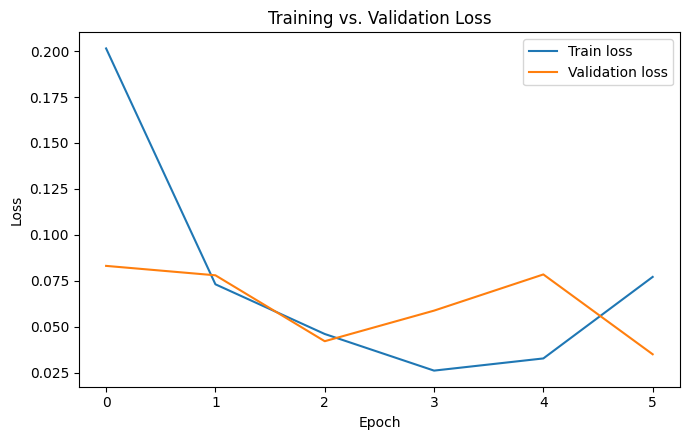

In [9]:
plt.figure(figsize=(7, 4.5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training vs. Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Evaluation

In [10]:
y_true, y_pred_proba = [], []
for x_batch, y_batch in validation_generator:
    preds = keras_model.predict(x_batch, verbose=0).ravel()
    y_pred_proba.extend(preds)
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true)
y_pred = (np.array(y_pred_proba) >= 0.5).astype(int)

print(f"Validation accuracy: {accuracy_score(y_true, y_pred):.4f}")


Validation accuracy: 0.9817


## 5. Save the trained model (needed for later labs)

In [11]:
keras_model.save("keras_cnn_classifier.keras")
print("Saved model to keras_cnn_classifier.keras")


Saved model to keras_cnn_classifier.keras


## Summary

We built a robust data pipeline (`fnames` via `os.walk`, plus
`validation_generator`), a CNN with 4 `Conv2D` layers and 5 `Dense`
layers (compiled with Adam + binary cross-entropy), counted the model's
total layers, configured a `ModelCheckpoint` callback tracking maximum
validation accuracy, trained the model, and plotted training vs.
validation loss to check for overfitting.
